In [1]:
import numpy as np
import pandas as pd
import math
import random

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings; warnings.filterwarnings(action='once')

large = 22; med = 16; small = 12
params = {'axes.titlesize': large,
          'legend.fontsize': med,
          'figure.figsize': (16, 10),
          'axes.labelsize': med,
          'axes.titlesize': med,
          'xtick.labelsize': med,
          'ytick.labelsize': med,
          'figure.titlesize': large}

plt.rcParams.update(params)
plt.style.use('seaborn-whitegrid')
sns.set_style("white")
%matplotlib inline

### Readin data of broadcast_view

```
SELECT bv.partition_time
     , bv.viewer_network || ':' || bv.viewer_member_id AS id
     , bv.viewer_member_id
     , bv.viewer_network
     , bv.broadcast_id
     , bv.view_start_time
     , bv.viewer_gender
     , bv.viewer_country
     , bv.view_source
     , MIN(view_end_time)  AS view_end_time
FROM (SELECT body_socialnetwork_memberid AS viewer_member_id
           , body_socialnetwork_name     AS viewer_network
           , body_broadcast_id           AS broadcast_id
           , body_publishedtime          AS view_start_time
           , body_viewer_gender          AS viewer_gender
           , body_viewer_ipcciso         AS viewer_country
           , body_broadcast_source       AS view_source
           , processing_time
           , partition_time
      FROM tmg.s_tmg_broadcast_view
      WHERE partition_time >= date_add('day', -7, CURRENT_DATE)
        AND partition_time < CURRENT_DATE
        AND LOWER(body_broadcast_source) LIKE '%for_you%'
        AND LOWER(body_broadcast_source) NOT LIKE '%fallback%'
        AND body_socialnetwork_name IN ('meetme')) bv
     LEFT JOIN (SELECT body_socialnetwork_memberid       AS viewer_member_id
                     , body_broadcast_id                 AS broadcast_id
                     , body_socialnetwork_name           AS viewer_network
                     , from_unixtime(body_publishedtime) AS view_end_time
                     , body_broadcast_viewduration       AS view_duration
                FROM tmg.s_tmg_broadcast_end_view
                WHERE partition_time >= date_add('day', -7, CURRENT_DATE)
                  AND partition_time < CURRENT_DATE) bve
               ON bv.viewer_member_id = bve.viewer_member_id 
                      AND bv.broadcast_id = bve.broadcast_id 
                      AND bv.viewer_network = bve.viewer_network 
                      AND bve.view_end_time >= bv.view_start_time
GROUP BY 1, 2, 3, 4, 5, 6, 7, 8, 9
)
```

Method to fetch the assignment

- clone this repo https://github.meetmecorp.com/Machine-Learning/tmg-ml-candidate-api
- run npm install inside that repo
- put this file in the parent of that cloned repo https://github.meetmecorp.com/gist/crahman/d97f434230bfbb4aa96c3567583f06bb
- update this line https://github.meetmecorp.com/gist/crahman/d97f434230bfbb4aa96c3567583f06bb#file-convertids-js-L15 to match where you downloaded your file
- https://github.meetmecorp.com/gist/crahman/d97f434230bfbb4aa96c3567583f06bb#file-convertids-js-L18 you may need to - update this if you use a different query but no need here
- run node convertIds.js > results_with_experiment.csv

once that is complete results_with_experiment.csv  will contain two new columns what experiment the user is in and what bucket they are in. mostly you will care about what experiment primary = old cold model beta = new beta model

In [2]:
!ls ../../../git/tmg-ml-candidate-api/results_with_experiment.csv

../../../git/tmg-ml-candidate-api/results_with_experiment.csv


In [3]:
assignment = pd.read_csv("../../../git/tmg-ml-candidate-api/results_with_experiment.csv", 
                         names=["partition_time","id","viewer_member_id","viewer_network","broadcast_id","view_start_time","viewer_gender","viewer_country","view_source","view_end_time", "assignment", "bucket"])
assignment.head()

,partition_time,id,viewer_member_id,viewer_network,broadcast_id,view_start_time,viewer_gender,viewer_country,view_source,view_end_time,assignment,bucket
0,2022-02-21,meetme:217101256,217101256,meetme,UZ3yPPjYuA,2022-02-21 10:00:16.000,female,US,for_you_recommended,2022-02-21 10:02:09.000,beta,2434
1,2022-02-21,meetme:308976519,308976519,meetme,TEMeeLtgD3,2022-02-21 10:00:29.000,male,DZ,for_you_swipe,2022-02-21 10:00:31.000,primary,6345
2,2022-02-21,meetme:77573456,77573456,meetme,6pqAbZ5izJ,2022-02-21 10:00:33.000,male,DE,for_you_recommended,2022-02-21 10:01:09.000,beta,3110
3,2022-02-21,meetme:291517020,291517020,meetme,kcahSFzE4Q,2022-02-21 10:00:37.000,male,US,for_you_recommended_swipe,2022-02-21 10:01:13.000,beta,2933
4,2022-02-21,meetme:291517020,291517020,meetme,Cp7RAuOCcm,2022-02-21 10:01:14.000,male,US,for_you_recommended_swipe,2022-02-21 10:03:14.000,beta,2933


In [4]:
assignment.bucket.describe()

count    3.537895e+06
mean     4.970145e+03
std      2.881460e+03
min      0.000000e+00
25%      2.448000e+03
50%      4.939000e+03
75%      7.456000e+03
max      9.999000e+03
Name: bucket, dtype: float64

In [5]:
assignment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3537895 entries, 0 to 3537894
Data columns (total 12 columns):
partition_time      object
id                  object
viewer_member_id    int64
viewer_network      object
broadcast_id        object
view_start_time     object
viewer_gender       object
viewer_country      object
view_source         object
view_end_time       object
assignment          object
bucket              int64
dtypes: int64(2), object(10)
memory usage: 323.9+ MB


In [6]:
assignment['assignment'].value_counts()

beta       1789901
primary    1747994
Name: assignment, dtype: int64

In [7]:
res = assignment['partition_time'].value_counts().reset_index(name="cnt")
res.sort_values(ascending=True, by='index')

,index,cnt
3,2022-02-15,504560
6,2022-02-16,466755
0,2022-02-17,543573
5,2022-02-18,492986
1,2022-02-19,519937
2,2022-02-20,515734
4,2022-02-21,494350


In [8]:
assignment.groupby('partition_time')['viewer_member_id'].nunique()

partition_time
2022-02-15    53303
2022-02-16    50261
2022-02-17    55675
2022-02-18    51717
2022-02-19    53139
2022-02-20    52944
2022-02-21    52452
Name: viewer_member_id, dtype: int64

In [9]:
assignment.groupby(['viewer_network'])['id'].count()

viewer_network
meetme    3537895
Name: id, dtype: int64

In [10]:
assignment.groupby(['partition_time', 'assignment'])['id'].count()

partition_time  assignment
2022-02-15      beta          254502
                primary       250058
2022-02-16      beta          234961
                primary       231794
2022-02-17      beta          274306
                primary       269267
2022-02-18      beta          252602
                primary       240384
2022-02-19      beta          265289
                primary       254648
2022-02-20      beta          257148
                primary       258586
2022-02-21      beta          251093
                primary       243257
Name: id, dtype: int64

## t tests

In [11]:
agg = pd.pivot_table(assignment, index = ['partition_time'], columns=['assignment'], values=['id'], aggfunc=len)

In [12]:
agg = agg.reset_index()

In [13]:
agg.columns = ['partition_date', 'coldBeta', 'cold']

In [14]:
agg

,partition_date,coldBeta,cold
0,2022-02-15,254502,250058
1,2022-02-16,234961,231794
2,2022-02-17,274306,269267
3,2022-02-18,252602,240384
4,2022-02-19,265289,254648
5,2022-02-20,257148,258586
6,2022-02-21,251093,243257


In [15]:
agg['diff'] = agg['cold'] - agg['coldBeta']

In [38]:
from scipy import stats

In [17]:
mu0 = 0
significance = 0.05

t_statistic, p_value = stats.ttest_1samp(agg['diff'] , mu0)
print(f"t stat: {t_statistic}, p value: {p_value}")

if p_value <= significance:
    print("Reject H0 in favour of H1: mu != 0.0")
else:
    print("Accept H0: mu = 0.0")
# Reject H0 in favour of H1: mu != 0.0

t stat: -3.399357803782423, p value: 0.014507395544868903
Reject H0 in favour of H1: mu != 0.0


### ChiSquare

In [18]:
assignment.head()

,partition_time,id,viewer_member_id,viewer_network,broadcast_id,view_start_time,viewer_gender,viewer_country,view_source,view_end_time,assignment,bucket
0,2022-02-21,meetme:217101256,217101256,meetme,UZ3yPPjYuA,2022-02-21 10:00:16.000,female,US,for_you_recommended,2022-02-21 10:02:09.000,beta,2434
1,2022-02-21,meetme:308976519,308976519,meetme,TEMeeLtgD3,2022-02-21 10:00:29.000,male,DZ,for_you_swipe,2022-02-21 10:00:31.000,primary,6345
2,2022-02-21,meetme:77573456,77573456,meetme,6pqAbZ5izJ,2022-02-21 10:00:33.000,male,DE,for_you_recommended,2022-02-21 10:01:09.000,beta,3110
3,2022-02-21,meetme:291517020,291517020,meetme,kcahSFzE4Q,2022-02-21 10:00:37.000,male,US,for_you_recommended_swipe,2022-02-21 10:01:13.000,beta,2933
4,2022-02-21,meetme:291517020,291517020,meetme,Cp7RAuOCcm,2022-02-21 10:01:14.000,male,US,for_you_recommended_swipe,2022-02-21 10:03:14.000,beta,2933


In [19]:
data_crosstab = pd.crosstab(index = assignment['partition_time'],
                            columns = assignment['assignment'],
                            values = assignment['id'],
                            aggfunc = len,
                            margins=True, margins_name="Total")

In [20]:
data_crosstab

assignment,beta,primary,Total
partition_time,,,
2022-02-15,254502,250058,504560
2022-02-16,234961,231794,466755
2022-02-17,274306,269267,543573
2022-02-18,252602,240384,492986
2022-02-19,265289,254648,519937
2022-02-20,257148,258586,515734
2022-02-21,251093,243257,494350
Total,1789901,1747994,3537895


In [21]:
# significance level
alpha = 0.05

# Calcualtion of Chisquare test statistics
chi_square = 0
rows = assignment['partition_time'].unique()
print(rows)
columns = assignment['assignment'].unique()
print(columns)

['2022-02-21' '2022-02-15' '2022-02-19' '2022-02-17' '2022-02-20'
 '2022-02-18' '2022-02-16']
['beta' 'primary']


In [22]:
for i in columns:
    for j in rows:
        O = data_crosstab[i][j]
        E = data_crosstab[i]['Total'] * data_crosstab['Total'][j] / data_crosstab['Total']['Total']
        chi_square += (O-E)**2/E

In [23]:
# The p-value approach
print("Approach 1: The p-value approach to hypothesis testing in the decision rule")
p_value = 1 - stats.norm.cdf(chi_square, (len(rows)-1)*(len(columns)-1))
conclusion = "Failed to reject the null hypothesis."
if p_value <= alpha:
    conclusion = "Null Hypothesis is rejected."
        
print("chisquare-score is:", chi_square, " and p value is:", p_value)
print(conclusion)

Approach 1: The p-value approach to hypothesis testing in the decision rule
chisquare-score is: 259.7864147383465  and p value is: 0.0
Null Hypothesis is rejected.


### Duration

In [11]:
missing_values = assignment.isnull().values.any()

In [12]:
missing_values

True

In [13]:
assignment[assignment.isnull().any(axis=1)]

,partition_time,id,viewer_member_id,viewer_network,broadcast_id,view_start_time,viewer_gender,viewer_country,view_source,view_end_time,assignment,bucket
49,2022-02-15,meetme:321100513,321100513,meetme,kVRSUP9qQk,2022-02-15 09:42:58.000,female,US,for_you_recommended,NaN,beta,4294
138,2022-02-19,meetme:267279872,267279872,meetme,KChqHkCVSq,2022-02-19 16:16:24.000,male,US,for_you,NaN,primary,6106
169,2022-02-19,meetme:328609397,328609397,meetme,R21HPVO0Bg,2022-02-19 16:24:42.000,female,GH,for_you_recommended,NaN,beta,2204
290,2022-02-21,meetme:328924271,328924271,meetme,GnB2OsFiKo,2022-02-21 03:38:05.000,male,IT,for_you_recommended_swipe,NaN,beta,2518
332,2022-02-21,meetme:324074507,324074507,meetme,DQXlP0ZfJE,2022-02-21 03:50:59.000,female,BR,for_you_recommended_swipe,NaN,primary,5416
...,...,...,...,...,...,...,...,...,...,...,...,...
3537711,2022-02-21,meetme:228068191,228068191,meetme,V2bhHy6iN2,2022-02-21 13:04:37.000,male,US,for_you,NaN,beta,800
3537760,2022-02-21,meetme:328630292,328630292,meetme,kAXRPm3RUR,2022-02-21 13:23:20.000,female,ID,for_you_recommended,NaN,primary,7104
3537814,2022-02-18,meetme:305359840,305359840,meetme,GU5bqzkDVl,2022-02-18 02:46:12.000,female,US,for_you,NaN,primary,9607
3537848,2022-02-18,meetme:318468979,318468979,meetme,k4CRYhzoiY,2022-02-18 02:56:31.000,female,US,for_you,NaN,primary,7632


In [14]:
len(assignment[assignment.isnull().any(axis=1)])/len(assignment)

0.02982423164056593

In [15]:
df = assignment.copy()

In [16]:
df.dropna(inplace=True)

In [17]:
from datetime import datetime, timedelta

In [18]:
df['view_start_time'] = df['view_start_time'].apply(lambda x: datetime.strptime(x, "%Y-%m-%d %H:%M:%S.%f"))

In [19]:
df['view_end_time'] = df['view_end_time'].apply(lambda x: datetime.strptime(x, "%Y-%m-%d %H:%M:%S.%f"))

In [20]:
df['duration'] = df[['view_start_time', 'view_end_time']].apply(lambda x: (x[1] - x[0]).seconds, axis=1)

In [21]:
df['duration'].describe()

count    3.432380e+06
mean     1.103139e+02
std      8.954415e+02
min      0.000000e+00
25%      4.000000e+00
50%      1.000000e+01
75%      4.100000e+01
max      8.623200e+04
Name: duration, dtype: float64

In [22]:
df.loc[(df['assignment'] == 'beta'), 'duration'].describe()

count    1.737025e+06
mean     1.092930e+02
std      8.753631e+02
min      0.000000e+00
25%      4.000000e+00
50%      1.000000e+01
75%      4.000000e+01
max      8.623200e+04
Name: duration, dtype: float64

In [23]:
df.loc[(df['assignment'] == 'primary'), 'duration'].describe()

count    1.695355e+06
mean     1.113598e+02
std      9.155559e+02
min      0.000000e+00
25%      4.000000e+00
50%      1.000000e+01
75%      4.100000e+01
max      8.604100e+04
Name: duration, dtype: float64

### Group Comparisons

In [24]:
cat_features = ['partition_time', 'viewer_gender', 'viewer_country', 'view_source']

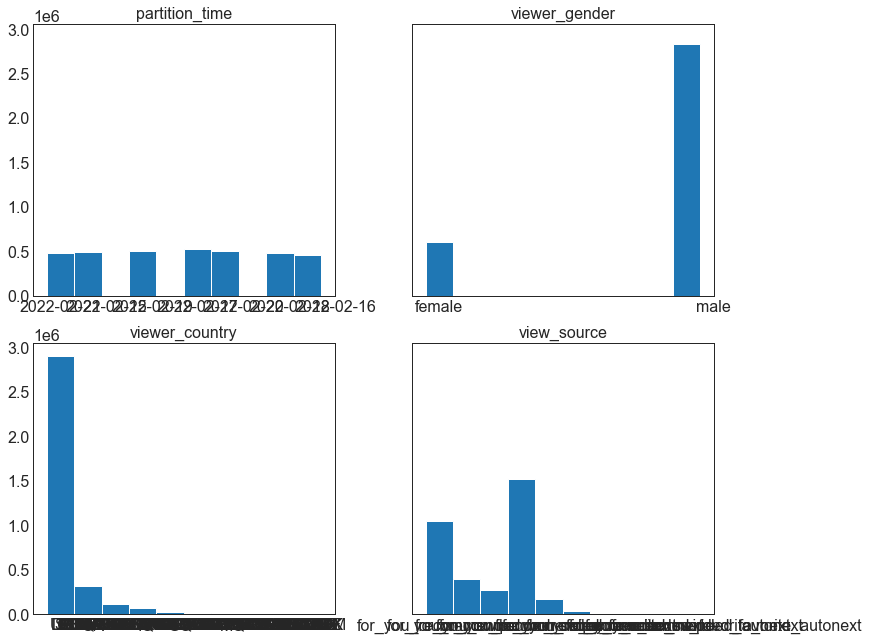

In [25]:
fig,axs = plt.subplots(2,2,figsize=(12,9),sharey=True)

for ax,feat in zip(axs.flatten(),cat_features):
    ax.hist(df[feat],align='left')
    ax.set_title(feat)
plt.tight_layout()

#### Distribution by partition time and assignment 

In [26]:
((pd.crosstab(df['assignment'],df['partition_time'])) / (pd.crosstab(df['assignment'], df['partition_time']).sum())).T

assignment,beta,primary
partition_time,,
2022-02-15,0.504232,0.495768
2022-02-16,0.503631,0.496369
2022-02-17,0.504826,0.495174
2022-02-18,0.512369,0.487631
2022-02-19,0.510721,0.489279
2022-02-20,0.499089,0.500911
2022-02-21,0.507733,0.492267


<AxesSubplot:xlabel='partition_time'>

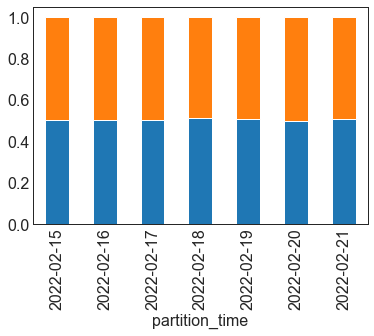

In [27]:
((pd.crosstab(df['assignment'],df['partition_time'])) / (pd.crosstab(df['assignment'], df['partition_time']).sum())).T.plot.bar(stacked=True,legend=False,title=None)

In [28]:
grp_mean = df.groupby(['partition_time', 'assignment'])['duration'].mean().reset_index()
grp_mean_pivot = grp_mean.pivot(index='partition_time', columns='assignment',values='duration').reset_index()
grp_mean_pivot

assignment,partition_time,beta,primary
0,2022-02-15,111.488036,114.357496
1,2022-02-16,110.939752,113.382893
2,2022-02-17,111.489133,115.149372
3,2022-02-18,106.869639,114.115511
4,2022-02-19,107.042074,110.284815
5,2022-02-20,114.235485,108.292794
6,2022-02-21,102.867203,103.804291


In [39]:
grp_mean_pivot['diff'] = grp_mean_pivot['primary']  - grp_mean_pivot['beta']

In [40]:
mu0 = 0
significance = 0.05

t_statistic, p_value = stats.ttest_1samp(grp_mean_pivot['diff'] , mu0)
print(f"t stat: {t_statistic}, p value: {p_value}")

if p_value <= significance:
    print("Reject H0 in favour of H1: mu != 0.0")
else:
    print("Accept H0: mu = 0.0")
# Reject H0 in favour of H1: mu != 0.0

t stat: 1.3591793801991459, p value: 0.22295498954609788
Accept H0: mu = 0.0


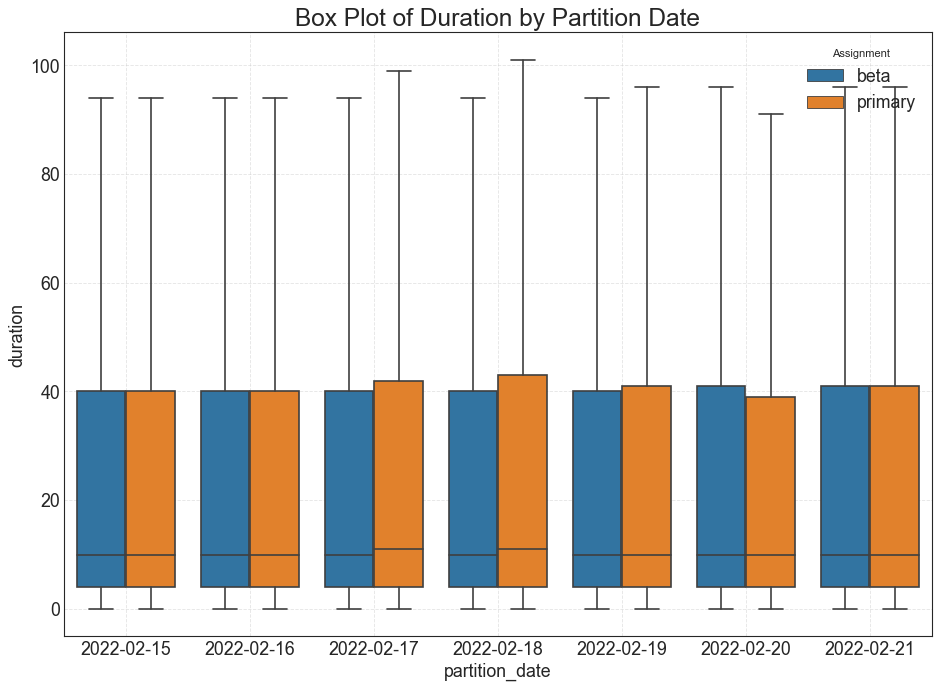

In [37]:
plt.figure(figsize=(14,10), dpi= 80)
sns.boxplot(x='partition_time', 
            y='duration', 
            hue='assignment', 
            data=df, 
            notch=False, 
            showfliers=False,
            order=['2022-02-15', '2022-02-16', '2022-02-17', '2022-02-18', '2022-02-19', '2022-02-20', '2022-02-21'])

# Decorations
plt.gca().set(xlabel='partition_date', ylabel='duration')
plt.title('Box Plot of Duration by Partition Date', fontsize=22)
plt.grid(linestyle='--', alpha=0.5)
plt.legend(loc='upper right', title='Assignment')
plt.show()

#### Distribution by gender and assignment

In [79]:
((pd.crosstab(df['assignment'],df['viewer_gender'])) / (pd.crosstab(df['assignment'], df['viewer_gender']).sum())).T

assignment,beta,primary
viewer_gender,,
female,0.505505,0.494495
male,0.506191,0.493809


<AxesSubplot:xlabel='viewer_gender'>

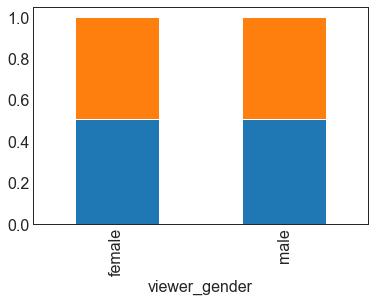

In [80]:
((pd.crosstab(df['assignment'],df['viewer_gender'])) / (pd.crosstab(df['assignment'], df['viewer_gender']).sum())).T.plot.bar(stacked=True,legend=False,title=None)

In [131]:
grp_mean = df.groupby(['viewer_gender', 'assignment'])['duration'].mean().reset_index()
grp_mean_pivot = grp_mean.pivot(index='viewer_gender', columns='assignment',values='duration').reset_index()
grp_mean_pivot

assignment,viewer_gender,beta,primary
0,female,201.059615,197.838967
1,male,89.616850,92.766362


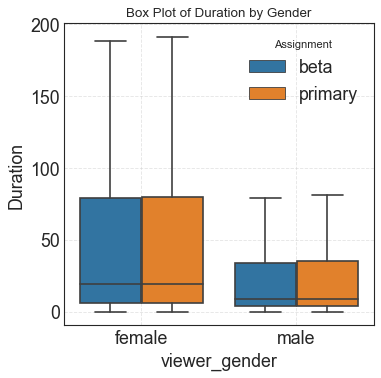

In [135]:
plt.figure(figsize=(5,5), dpi= 80)
sns.boxplot(x='viewer_gender', y='duration', hue='assignment', data=df, notch=False, showfliers=False)

# Decorations
plt.gca().set(xlabel='viewer_gender', ylabel='Duration')
plt.title('Box Plot of Duration by Gender', fontsize=12)
plt.grid(linestyle='--', alpha=0.5)
plt.legend(loc='upper right', title='Assignment')
plt.show()

#### Distribution by top 10 countries and assignment 

In [90]:
df['viewer_country'].value_counts().sort_values(ascending=False).head(10)

US    1765832
GB     171567
IN     151631
BR     125868
TR     107020
PH      90954
ID      84519
CA      75299
MX      67106
SA      58197
Name: viewer_country, dtype: int64

In [94]:
top10_country = ['US', 'GB', 'IN', 'BR', 'TR', 'PH', 'ID', 'CA', 'MX', 'SA']

In [96]:
df['top10_country'] = df['viewer_country'].apply(lambda x: x if (x in top10_country) else 'Other')

In [98]:
((pd.crosstab(df['assignment'],df['top10_country'])) / (pd.crosstab(df['assignment'], df['top10_country']).sum())).T

assignment,beta,primary
top10_country,,
BR,0.486629,0.513371
CA,0.475464,0.524536
GB,0.518281,0.481719
ID,0.473763,0.526237
IN,0.497458,0.502542
MX,0.532903,0.467097
Other,0.516963,0.483037
PH,0.500385,0.499615
SA,0.573878,0.426122


<AxesSubplot:xlabel='top10_country'>

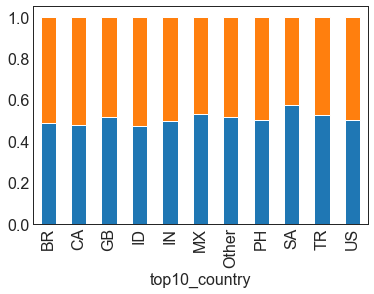

In [100]:
((pd.crosstab(df['assignment'],df['top10_country'])) / (pd.crosstab(df['assignment'], df['top10_country']).sum())).T.plot.bar(stacked=True,legend=False,title=None)

In [136]:
grp_mean = df.groupby(['top10_country', 'assignment'])['duration'].mean().reset_index()
grp_mean_pivot = grp_mean.pivot(index='top10_country', columns='assignment',values='duration').reset_index()
grp_mean_pivot

assignment,top10_country,beta,primary
0,BR,129.598260,134.668029
1,CA,139.261047,156.334532
2,GB,123.632164,119.482135
3,ID,140.669747,158.048519
4,IN,72.593212,66.791276
5,MX,68.007159,68.514053
6,Other,88.744910,92.517165
7,PH,110.412419,115.084569
8,SA,56.689981,49.844994
9,TR,76.793187,86.379431


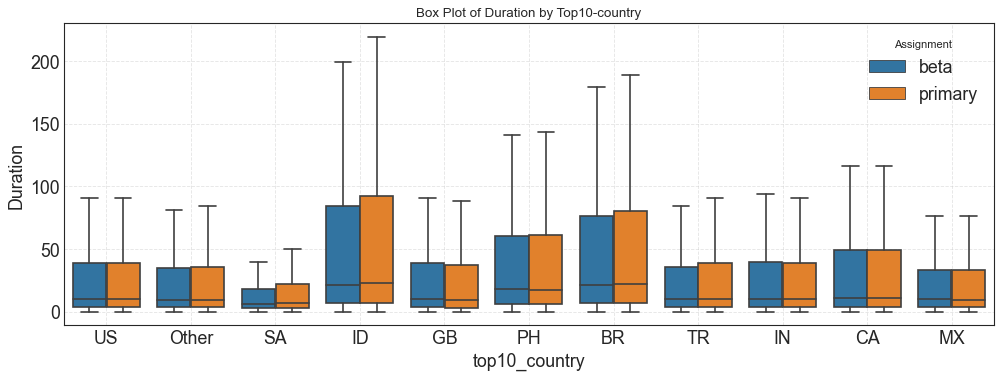

In [139]:
plt.figure(figsize=(15,5), dpi= 80)
sns.boxplot(x='top10_country', y='duration', hue='assignment', data=df, notch=False, showfliers=False)

# Decorations
plt.gca().set(xlabel='top10_country', ylabel='Duration')
plt.title('Box Plot of Duration by Top10-country', fontsize=12)
plt.grid(linestyle='--', alpha=0.5)
plt.legend(loc='upper right', title='Assignment')
plt.show()